In [2]:
import torch 
import gymnasium as gym 
import matplotlib.pyplot as plt 
import cv2 as cv
import torch.nn as nn
import random
import numpy as np
from torch import optim
import copy
from scipy import stats
%matplotlib inline

In [3]:
env = gym.make('MountainCar-v0', render_mode="rgb_array")


In [4]:
obs, info = env.reset()


In [5]:
def show_animation():
    obs, info = env.reset()
    t = 0
    truncated = False
    while True:
        action = env.action_space.sample()
        obs, reward, terminated, _, info = env.step(action)
        frame = env.render() 
        frame = cv.cvtColor(frame, cv.COLOR_RGB2BGR)
        cv.imshow("Acrobot", frame)
        if cv.waitKey(30) & 0xFF == ord('q'):
            break
        t += 1
        if t == 2000:
            truncated = True
        if terminated or truncated:
            obs, info = env.reset()
            truncated = False
            t = 0
    cv.destroyAllWindows()

In [6]:
# show_animation()

In [7]:
class QNetwork(nn.Module):
    def __init__(self, state_dim=2, action_dim=3, hidden_dim=64):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
    
    def forward(self, x):
        return self.net(x)

In [8]:
def train_dqn(seed, num_episodes=500, rho=1):
    env = gym.make('MountainCar-v0', render_mode="rgb_array")
    obs, info = env.reset()
    

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    env = gym.wrappers.TimeLimit(env.env, max_episode_steps=2000)
    
    min_buffer_size = 1000
    
    policy_net = QNetwork(2, 3)
    target_net = QNetwork(2, 3)
    target_net.load_state_dict(policy_net.state_dict())
    optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)
    
    buffer_capacity = 50000
    b_states = np.zeros((buffer_capacity, 2), dtype=np.float32)
    b_next_states = np.zeros((buffer_capacity, 2), dtype=np.float32)
    b_actions = np.zeros(buffer_capacity, dtype=np.int64)
    b_rewards = np.zeros(buffer_capacity, dtype=np.float32)
    b_dones = np.zeros(buffer_capacity, dtype=np.float32)
    
    buffer_ptr, buffer_size = 0, 0
    gamma, batch_size, target_update_freq = 0.99, 64, 1000 
    eps, eps_min, eps_decay = 1.0, 0.01, 0.995
    total_steps, episode_returns = 0, []
    best_return = -2001

    for ep in range(num_episodes):
        state, _ = env.reset(seed=seed)
        ep_ret, done = 0, False
        
        while not done:
            if random.random() < eps:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    action = policy_net(torch.FloatTensor(state)).argmax().item()
            
            next_s, rew, term, trunc, _ = env.step(action)
            done = term or trunc
            
           
            b_states[buffer_ptr] = state
            b_next_states[buffer_ptr] = next_s
            b_actions[buffer_ptr] = action
            b_rewards[buffer_ptr] = rew
            b_dones[buffer_ptr] = float(term) 
            
            buffer_ptr = (buffer_ptr + 1) % buffer_capacity
            buffer_size = min(buffer_size + 1, buffer_capacity)
            state = next_s
            ep_ret += rew
            total_steps += 1
            if buffer_size > min_buffer_size:
                for _ in range(rho):
                    idx = np.random.choice(buffer_size, batch_size, replace=False) 
                    
                    s_batch = torch.FloatTensor(b_states[idx])
                    ns_batch = torch.FloatTensor(b_next_states[idx])
                    a_batch = torch.LongTensor(b_actions[idx]).view(-1, 1)
                    r_batch = torch.FloatTensor(b_rewards[idx]).view(-1, 1)
                    d_batch = torch.FloatTensor(b_dones[idx]).view(-1, 1)
                    
                    # only get the q value of the action chosen 
                    current_q = policy_net(s_batch).gather(1, a_batch)


                    with torch.no_grad():
                        max_next_q = target_net(ns_batch).max(1)[0].view(-1, 1) # .view() for reshaping
                        target_q = r_batch + (gamma * max_next_q * (1 - d_batch)) # if reached d_batch = 1 and only reward counted
                    
                    loss = nn.MSELoss()(current_q, target_q)
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
            
            if total_steps % target_update_freq == 0:
                target_net.load_state_dict(policy_net.state_dict())
        
        eps = max(eps_min, eps * eps_decay)
        print(f"Return {ep_ret} actived in {ep} episode")
        episode_returns.append(ep_ret)
        if ep_ret > best_return:
            best_state_dict = copy.deepcopy(policy_net.state_dict()) 
        
    env.close()
    return episode_returns, policy_net.state_dict(), best_state_dict

In [ ]:
for i in range(15):
    returns, state_dict, best_dict = train_dqn(1, num_episodes=2)
    np.save(f"reurns_1_seed{i}.npy", returns)
    torch.save(state_dict, f"last_dict_seed{i}.pt")
    torch.save(best_dict, f"best_dict_seed{i}.pt")

Return -2000.0 actived in 0 episode
Return -2000.0 actived in 1 episode


In [9]:
def run_network(policy_net, env_id='MountainCar-v0', num_test_episodes=5, max_steps=1000, show_animation=True):
    env = gym.make(env_id, render_mode="rgb_array")
    env = gym.wrappers.TimeLimit(env.env, max_episode_steps=max_steps)
    
    returns = []
    policy_net.eval()  
    for ep in range(num_test_episodes):
        state, _ = env.reset()
        ep_ret, t = 0, 0
        done = False
        if show_animation:
            print(f"--- Starting Evaluation Episode {ep + 1} ---")
        
        while not done:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).unsqueeze(0) 
                action = policy_net(state_t).argmax().item()
            
            next_s, rew, term, trunc, _ = env.step(action)
            done = term or trunc
            
            frame = env.render() 
            if show_animation:
                frame = cv.cvtColor(frame, cv.COLOR_RGB2BGR)
                
                cv.putText(frame, f"Ep: {ep+1} Step: {t} Ret: {int(ep_ret)}", 
                        (10, 30), cv.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)
                
                cv.imshow(f"DQN Evaluation: {env_id}", frame)
                
                if cv.waitKey(30) & 0xFF == ord('q'):
                    print("Evaluation aborted by user.")
                    cv.destroyAllWindows()
                    env.close()
                    return
            
            state = next_s
            ep_ret += rew
            t += 1
        returns.append(ep_ret)
        if show_animation:
            print(f"Episode {ep + 1} finished | Return: {ep_ret} | Total Steps: {t}")
    
    if show_animation:
        cv.destroyAllWindows()
    env.close()
    return returns

In [10]:


def run_network_and_save_video(
    policy_net,
    env_id='MountainCar-v0',
    max_steps=1000,
    video_path="dqn_eval.mp4",
    fps=30,
    show_animation=False
):
    env = gym.make(env_id, render_mode="rgb_array")
    env = gym.wrappers.TimeLimit(env.env, max_episode_steps=max_steps)

    policy_net.eval()

    state, _ = env.reset()
    done = False
    ep_ret, t = 0, 0

    print("--- Starting Evaluation Episode ---")

    # Initialize video writer AFTER first frame (to get shape)
    frame = env.render()
    frame = cv.cvtColor(frame, cv.COLOR_RGB2BGR)
    h, w, _ = frame.shape

    fourcc = cv.VideoWriter_fourcc(*'mp4v')
    video_writer = cv.VideoWriter(video_path, fourcc, fps, (w, h))

    while not done:
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0)
            action = policy_net(state_t).argmax().item()

        next_s, rew, term, trunc, _ = env.step(action)
        done = term or trunc

        frame = env.render()
        frame = cv.cvtColor(frame, cv.COLOR_RGB2BGR)

        # Overlay info
        cv.putText(frame, f"Step: {t} Ret: {int(ep_ret)}",
                   (10, 30), cv.FONT_HERSHEY_SIMPLEX,
                   0.7, (0, 0, 0), 2)

        # Write frame to video
        video_writer.write(frame)

        # Optional display
        if show_animation:
            cv.imshow(f"DQN Evaluation: {env_id}", frame)
            if cv.waitKey(30) & 0xFF == ord('q'):
                print("Evaluation aborted by user.")
                break

        state = next_s
        ep_ret += rew
        t += 1

    video_writer.release()

    if show_animation:
        cv.destroyAllWindows()

    env.close()

    print(f"Episode finished | Return: {ep_ret} | Steps: {t}")
    print(f"Video saved to: {video_path}")

    return ep_ret

In [62]:
p_net = QNetwork()
p_net.load_state_dict(torch.load(fr"results\results_vanilla_700eps\best_dict_seed7_700eps.pt"))
run_network_and_save_video(p_net, video_path="dqn_mountaincar_seed7.mp4", show_animation=True)

--- Starting Evaluation Episode ---
Episode finished | Return: -86.0 | Steps: 86
Video saved to: dqn_mountaincar_seed7.mp4


-86.0

In [58]:
total = 0
for i in range(15):
    p_net = QNetwork()
    p_net.load_state_dict(torch.load(fr"results\results_vanilla_700eps\best_dict_seed{i}_700eps.pt"))
    returns = run_network(p_net, num_test_episodes=100, show_animation=False)
    total += np.mean(returns)
    print(f"seed {i}: avg {np.mean(returns)}: median {np.median(returns)} : max {np.max(returns)} : min {np.min(returns)}")
print(f"Overall average: {total/15}")

seed 0: avg -194.51: median -115.0 : max -111.0 : min -1000.0
seed 1: avg -108.5: median -105.0 : max -86.0 : min -136.0
seed 2: avg -149.71: median -111.0 : max -108.0 : min -1000.0
seed 3: avg -270.37: median -139.0 : max -132.0 : min -1000.0
seed 4: avg -502.58: median -197.0 : max -89.0 : min -1000.0
seed 5: avg -697.14: median -1000.0 : max -89.0 : min -1000.0
seed 6: avg -129.84: median -135.0 : max -108.0 : min -139.0
seed 7: avg -108.57: median -107.0 : max -86.0 : min -158.0
seed 8: avg -174.53: median -182.0 : max -95.0 : min -286.0
seed 9: avg -132.8: median -151.0 : max -83.0 : min -225.0
seed 10: avg -514.21: median -197.0 : max -89.0 : min -1000.0
seed 11: avg -159.17: median -110.0 : max -107.0 : min -1000.0
seed 12: avg -123.13: median -135.0 : max -84.0 : min -175.0
seed 13: avg -450.82: median -150.0 : max -86.0 : min -1000.0
seed 14: avg -121.97: median -132.0 : max -84.0 : min -137.0
Overall average: -255.8566666666667


In [55]:
p_net = QNetwork()
p_net.load_state_dict(torch.load(fr"results\results_vanilla_700eps\best_dict_seed7_700eps.pt"))
returns = run_network(p_net, num_test_episodes=10, show_animation=True)

--- Starting Evaluation Episode 1 ---
Episode 1 finished | Return: -87.0 | Total Steps: 87
--- Starting Evaluation Episode 2 ---
Episode 2 finished | Return: -87.0 | Total Steps: 87
--- Starting Evaluation Episode 3 ---
Episode 3 finished | Return: -121.0 | Total Steps: 121
--- Starting Evaluation Episode 4 ---
Episode 4 finished | Return: -155.0 | Total Steps: 155
--- Starting Evaluation Episode 5 ---
Episode 5 finished | Return: -117.0 | Total Steps: 117
--- Starting Evaluation Episode 6 ---
Episode 6 finished | Return: -104.0 | Total Steps: 104
--- Starting Evaluation Episode 7 ---
Episode 7 finished | Return: -87.0 | Total Steps: 87
--- Starting Evaluation Episode 8 ---
Episode 8 finished | Return: -104.0 | Total Steps: 104
--- Starting Evaluation Episode 9 ---
Episode 9 finished | Return: -114.0 | Total Steps: 114
--- Starting Evaluation Episode 10 ---
Episode 10 finished | Return: -103.0 | Total Steps: 103


In [11]:
def smooth(data, beta=0.9):
    smoothed = np.zeros_like(data)
    smoothed[0] = data[0]
    for i in range(1, len(data)):
        smoothed[i] = beta * smoothed[i-1] + (1 - beta) * data[i]
    return smoothed

In [72]:
t_crit = stats.t.ppf(0.95, df=14)
all_returns_2000 = np.array([np.load(f"results/results_vanilla_700eps/reurns_1_seed{i}_700eps.npy") for i in range(15)])
mean_returns_2000 = np.mean(all_returns_2000, axis=0)
confidence_interval_2000 = t_crit * (np.std(all_returns_2000, axis=0) / np.sqrt(15))
episodes = np.arange(1, mean_returns_2000.size + 1)

mean_smoothed_2000 = smooth(mean_returns_2000)
ci_smoothed_2000 = smooth(confidence_interval_2000)


In [73]:
all_returns_1000 = np.array([np.load(fr"results\1000_eps\reurns_1_seed{i}.npy") for i in range(15)])[:, :700]
mean_returns_1000 = np.mean(all_returns_1000, axis=0)
confidence_interval_1000 = t_crit * (np.std(all_returns_1000, axis=0) / np.sqrt(15))
episodes = np.arange(1, mean_returns_1000.size + 1)

mean_smoothed_1000 = smooth(mean_returns_1000)
ci_smoothed_1000 = smooth(confidence_interval_1000)



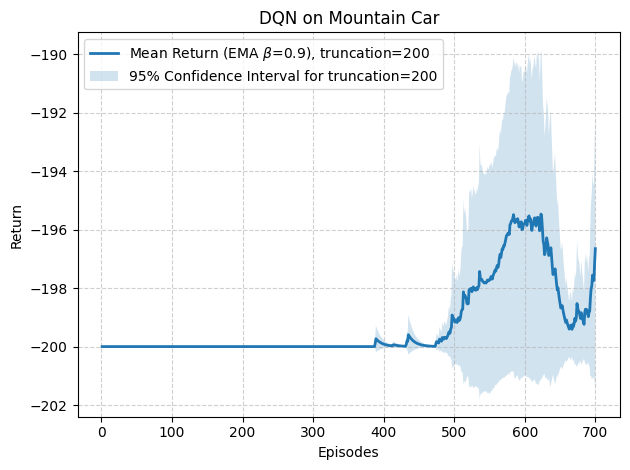

In [14]:
t_crit = stats.t.ppf(0.95, df=14)
all_returns_200 = np.array([np.load(fr"results\results_trun200\reurns_1_seed{i}_700eps_trun200.npy") for i in range(15)])[:, :700]
mean_returns_200 = np.mean(all_returns_200, axis=0)
confidence_interval_200 = t_crit * (np.std(all_returns_200, axis=0) / np.sqrt(15))
episodes = np.arange(1, mean_returns_200.size + 1)

mean_smoothed_200 = smooth(mean_returns_200)
ci_smoothed_200 = smooth(confidence_interval_200)


plt.plot(episodes, mean_smoothed_200, label=f'Mean Return (EMA $\\beta$=0.9), truncation=200',  linewidth=2)

plt.fill_between(episodes, mean_smoothed_200 - ci_smoothed_200, mean_smoothed_200 + ci_smoothed_200,  alpha=0.2, label='95% Confidence Interval for truncation=200')

# plt.plot(episodes, mean_smoothed_1000, label=f'Mean Return (EMA $\\beta$=0.9), truncation=1000', linewidth=2)

# plt.fill_between(episodes, mean_smoothed_1000 - ci_smoothed_1000, mean_smoothed_1000 + ci_smoothed_1000,  alpha=0.2, label='95% Confidence Interval for truncation=1000')

# plt.plot(episodes, mean_smoothed_2000, label=f'Mean Return (EMA $\\beta$=0.9), truncation=2000', linewidth=2)

# plt.fill_between(episodes, mean_smoothed_2000 - ci_smoothed_2000, mean_smoothed_2000 + ci_smoothed_2000,  alpha=0.2, label='95% Confidence Interval for truncation=2000')

plt.xlabel('Episodes')
plt.ylabel('Return')
plt.title('DQN on Mountain Car')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('dqn_mountain_car_learning_curve_trunc_200.png', dpi=300)
plt.show()

In [ ]:
class PrioritizedBuffer:
    def __init__(self, capacity, alpha=0.6):
        self.capacity = capacity
        self.alpha = alpha  
        self.buffer = []
        self.pos = 0
        self.priorities = np.zeros((capacity,), dtype=np.float32)
    
    def add(self, state, action, reward, next_state, done):
        max_prio = self.priorities.max() if self.buffer else 1.0
        
        if len(self.buffer) < self.capacity:
            self.buffer.append((state, action, reward, next_state, done))
        else:
            self.buffer[self.pos] = (state, action, reward, next_state, done)
        
        self.priorities[self.pos] = max_prio
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size, beta=0.4):
        if len(self.buffer) == self.capacity:
            prios = self.priorities
        else:
            prios = self.priorities[:self.pos]
        probs = prios ** self.alpha
        probs /= probs.sum()
        indices = np.random.choice(len(self.buffer), batch_size, p=probs)
        samples = [self.buffer[idx] for idx in indices]
        total = len(self.buffer)
        weights = (total * probs[indices]) ** (-beta)
        weights /= weights.max() 
        states, actions, rewards, next_states, dones = zip(*samples)
        return (np.array(states), np.array(actions), np.array(rewards, dtype=np.float32), np.array(next_states), np.array(dones, dtype=np.float32), indices, torch.FloatTensor(weights))

    def update_priorities(self, batch_indices, batch_priorities):
        for idx, prio in zip(batch_indices, batch_priorities):
            self.priorities[idx] = prio + 1e-6

def train_dqn_per(seed, num_episodes=500, rho=1):
    env = gym.make('MountainCar-v0')
    random.seed(seed) 
    np.random.seed(seed) 
    torch.manual_seed(seed)
    env = gym.wrappers.TimeLimit(env.env, max_episode_steps=2000)
    
    policy_net = QNetwork(2, 3); target_net = QNetwork(2, 3)
    target_net.load_state_dict(policy_net.state_dict())
    optimizer = optim.Adam(policy_net.parameters(), lr=1e-4) # PER often needs lower LR
    
    alpha, beta_start, beta_frames = 0.6, 0.4, 100000 
    buffer = PrioritizedBuffer(50000, alpha)
    
    gamma, batch_size, target_update_freq = 0.99, 64, 1000 
    eps, eps_min, eps_decay = 1.0, 0.01, 0.995
    total_steps, episode_returns = 0, []
    best_return = -2001

    for ep in range(num_episodes):
        state, _ = env.reset(seed=seed)
        ep_ret, done = 0, False
        
        while not done:
            if random.random() < eps:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    action = policy_net(torch.FloatTensor(state)).argmax().item()
            
            next_s, rew, term, trunc, _ = env.step(action)
            done = term or trunc
            buffer.add(state, action, rew, next_s, term)
            state, ep_ret, total_steps = next_s, ep_ret + rew, total_steps + 1

            if len(buffer.buffer) > 1000:
                for _ in range(rho):
                    beta = min(1.0, beta_start + total_steps * (1.0 - beta_start) / beta_frames)
                    
                    s_batch, a_batch, r_batch, ns_batch, d_batch, indices, weights = buffer.sample(batch_size, beta)
                    
                    s_tensor = torch.FloatTensor(s_batch)
                    ns_tensor = torch.FloatTensor(ns_batch)
                    a_tensor = torch.LongTensor(a_batch).view(-1, 1)
                    r_tensor = torch.FloatTensor(r_batch).view(-1, 1)
                    d_tensor = torch.FloatTensor(d_batch).view(-1, 1)

                    current_q = policy_net(s_tensor).gather(1, a_tensor)
                    with torch.no_grad():
                        max_next_q = target_net(ns_tensor).max(1)[0].view(-1, 1)
                        target_q = r_tensor + (gamma * max_next_q * (1 - d_tensor))
                    
                    td_errors = torch.abs(target_q - current_q).detach().numpy()
                    
                    loss = (weights.view(-1, 1) * nn.MSELoss(reduction='none')(current_q, target_q)).mean()
                    
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
                    
                    buffer.update_priorities(indices, td_errors.flatten())
            
            if total_steps % target_update_freq == 0:
                target_net.load_state_dict(policy_net.state_dict())
        
        eps = max(eps_min, eps * eps_decay)
        episode_returns.append(ep_ret)
        if ep_ret > best_return:
            best_return = ep_ret
            best_state_dict = copy.deepcopy(policy_net.state_dict()) 
            
    env.close()
    return episode_returns, policy_net.state_dict(), best_state_dict